# Cross Validation (CV):
1. Definition:
    - Cross-Validation is a resampling technique to estimate how well a model will generalize to unseen data.
    - It repeatedly splits the dataset into training and validation "folds", trains on some folds, evaluates on the held-out fold, and averages the scores.

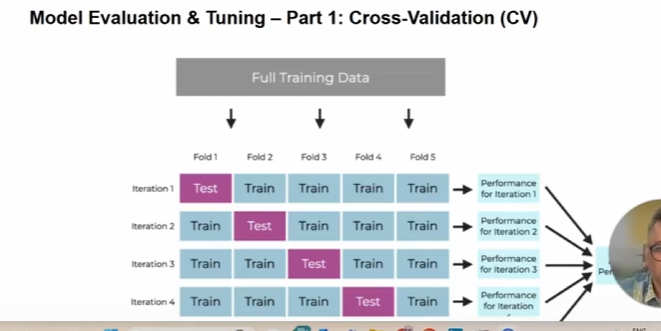

2. Comcept (What, Why, How):
    - What happens in k-fold CV?
        - Split data into k equal folds.
        - For each fold(i = 1..l): trains k-1 folds, validate on the held-out fold i.
        - Collect k scores -> report mean +- std (optionally 95% CI).
    - Why it matters?
        - Reduces variance from a lucky/unlucky single train test split.
        - Uses data more efficiently (each sample becomes validation exactly once).
        - More reliable model comparison across algorithms/hyperparameters.
    - Choosing the right strategy:
        - KFold: standard tabular data with i.i.d samples.
        - StratifiedKFold: classification with class imbalance -> keeps label ratios per fold.
        - GroupKFold: grouped data where sample from the group must not leak across train/val (e.g. - users, patients, stores).
        - TimeSeriesSplit: Ordered/temporal data -> train on the past, validate on the future (no shuffling).
    - Typical K values: 
        - Common: 5 or 10 folds.
        - Higher k -> lower bias but higher variance/computation.
        - Leave One out Cross Validation (LOOCV) (k = n) rarely needed; very expensive and ofter high variance.
    - Reporting Uncertainty
        - Report Mean +- std across folds.
        - Optional rough 95% CI: mean += 1.96*(std/ squareroot k) (note folds aren't fully independent, so CI is approximate).

    - Common Pitfalls
        - Data Leakage: Scaling/feature selection must be inside the CV loop -> Use Pipeline.
        - Shuffling: for i.i.d data, shuffle before split; never shuffle time series.
        - Wrong splitter: dont use plain Kfold for imbalanced classification or time series.
        - Using accuracy only: add precision/recall/F1/ROC-AUC for balanced understanding

### 📌 Model Evaluation & Tuning – Part 2: GridSearchCV

---

### 1️⃣ Definition

**GridSearchCV** is a hyperparameter tuning technique that systematically searches over a **grid of parameters** for a given model.

- It uses **cross-validation** for each parameter combination.
- The **best combination** is selected based on performance metrics.

---

### 📌 Concept (What, Why, How)

#### What happens in GridSearchCV

- You define a **model** and a **grid of hyperparameters**.

- For each parameter combination:
  - Train and validate the model using **cross-validation**.
  - Record the **average performance**.

- Select the **best parameters** with the **highest CV score**.

### 📌 Why It Matters

- Hyperparameters (like **learning rate**, **tree depth**, **regularization strength**) strongly influence model performance.
- Manual tuning is **trial-and-error** and prone to **bias**.
- **GridSearchCV** provides a **systematic, reproducible** way to optimize models.

### 📌 Key Points

- **scoring** → choose the metric to optimize  
  *(accuracy, recall, F1, ROC-AUC, RMSE)*

- **cv** → cross-validation strategy  
  *(KFold, StratifiedKFold, TimeSeriesSplit)*

- **refit = True** → after finding best parameters, retrain model on the **full dataset**

- Computationally expensive if the grid is large →  
  use **RandomizedSearchCV** as an alternative



### 📌 Cross-Validation vs GridSearchCV

| Aspect        | Cross-Validation (Part 1)                                   | GridSearchCV (Part 2)                                   |
|---------------|---------------------------------------------------------------|----------------------------------------------------------|
| Purpose       | Evaluate model performance reliably                           | Tune model hyperparameters systematically                |
| What it does  | Splits dataset into **k** folds, trains on **k−1**, tests on 1, repeats | Tries all parameter combinations, uses CV for each, finds best |
| Output        | Mean ± std of chosen metric (accuracy, recall, etc.)          | Best hyperparameter set + best CV score                  |
| Focus         | Generalization ability                                        | Optimization of parameters                               |
| When to use   | Anytime you want robust evaluation                            | When model performance depends heavily on hyperparameters |
| Example       | Logistic Regression evaluated with 10-fold CV                | Random Forest tuned with 81 parameter combinations       |
